## STOCK TRADER BEHAVIOR CLUSTERING PROJECT

**1. Problem Statement**

A hedge fund and trading analytics firm wants to deeply understand trader behavior across its platform. Traders differ in terms of risk appetite, trading frequency, emotional discipline, leverage usage, and profitability. However, no predefined labels exist. The goal is to use unsupervised
learning to segment traders into meaningful behavioral clusters. These clusters will help in risk profiling, strategy optimization, trader performance monitoring, and personalized trading insights.

**2. Domain Knowledge**

Trading behavior is multi-dimensional: • High-frequency traders execute many trades with low holding time. • Swing traders focus on medium-term price movements. • Long-term investors prioritize stability and low risk. • High-risk traders use leverage aggressively and experience large
drawdowns. • Emotional traders show inconsistency and poor risk management. Key concepts: • Win Rate vs PnL: High win rate does not always mean profitability. • Leverage: Amplifies both profits and losses. • Drawdown: Measures risk exposure. • Emotional Trading: Leads to irrational
decisions. • Consistency: Indicates disciplined strategy execution.

**3. Data Dictionary**

**Feature**------**Description**

trades_per_day :- Number of trades executed daily

avg_trade_value :- Average value per trade

avg_holding_time_hours :- Duration trades are held

win_rate :- Percentage of profitable trades

risk_score :- Trader risk appetite score

monthly_pnl :- Profit and Loss

volatility_preference :- Preference for volatile markets

stop_loss_usage_ratio :- Risk management behavior

leverage_used :- Capital leverage used

max_drawdown :- Maximum loss experienced

emotional_trading_score :- Psychological instability indicator

consistency_score :- Stability of performance

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

In [3]:
df=pd.read_csv('stock_trader_behavior_dataset.csv');

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   trader_id                8000 non-null   object 
 1   market_type              8000 non-null   object 
 2   trader_style             8000 non-null   object 
 3   trades_per_day           8000 non-null   float64
 4   avg_trade_value          8000 non-null   float64
 5   avg_holding_time_hours   8000 non-null   float64
 6   win_rate                 7655 non-null   float64
 7   risk_score               8000 non-null   float64
 8   monthly_pnl              7604 non-null   float64
 9   volatility_preference    8000 non-null   float64
 10  stop_loss_usage_ratio    8000 non-null   float64
 11  leverage_used            8000 non-null   float64
 12  max_drawdown             8000 non-null   float64
 13  emotional_trading_score  8000 non-null   float64
 14  consistency_score       

In [5]:
df.head()

,trader_id,market_type,trader_style,trades_per_day,avg_trade_value,avg_holding_time_hours,win_rate,risk_score,monthly_pnl,volatility_preference,stop_loss_usage_ratio,leverage_used,max_drawdown,emotional_trading_score,consistency_score
0,TR000001,Options,long_term,22.32,10985.26,10.33,0.561,3.45,-11112.51,0.409,0.449,11.54,65.90,22.80,3.03
1,TR000002,Equity,swing_trader,33.91,5990.04,13.45,0.412,4.77,-29.59,0.314,0.700,13.37,76.90,43.06,1.00
2,TR000003,Crypto,day_trader,22.54,8250.57,0.10,0.365,6.31,4378.14,0.364,0.736,2.33,56.07,17.11,11.06
3,TR000004,Crypto,scalper,18.63,100.00,12.07,0.726,3.35,5693.85,0.803,0.282,8.22,56.28,25.37,12.02
4,TR000005,Equity,scalper,13.90,12148.27,0.10,0.618,7.09,-1301.55,0.659,0.160,13.67,100.00,40.93,10.32


In [6]:
df.describe()

,trades_per_day,avg_trade_value,avg_holding_time_hours,win_rate,risk_score,monthly_pnl,volatility_preference,stop_loss_usage_ratio,leverage_used,max_drawdown,emotional_trading_score,consistency_score
count,8000.000000,8000.00000,8000.000000,7655.000000,8000.000000,7604.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,20.139846,8047.11661,13.983186,0.548084,5.499545,32.611272,0.592171,0.548117,8.117759,56.877089,27.583860,12.718029
std,11.342962,4773.10783,14.877587,0.164351,2.878201,9987.409926,0.260956,0.245309,4.770030,25.281015,16.856537,11.655451
min,1.000000,100.00000,0.100000,0.111000,1.000000,-34229.100000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000
25%,11.810000,4481.96250,0.100000,0.421000,3.120000,-6753.672500,0.396000,0.363750,4.180000,38.617500,14.687500,1.000000
50%,19.840000,7931.03000,10.000000,0.545000,5.490000,-34.240000,0.598000,0.551000,7.990000,57.045000,26.910000,10.320000
75%,27.790000,11351.70500,23.540000,0.674000,7.920000,6846.980000,0.807000,0.736000,11.640000,75.942500,38.910000,20.510000
max,63.780000,29330.88000,75.510000,1.000000,10.000000,33859.000000,1.000000,1.000000,24.620000,100.000000,89.250000,63.040000


In [7]:
df.tail()

,trader_id,market_type,trader_style,trades_per_day,avg_trade_value,avg_holding_time_hours,win_rate,risk_score,monthly_pnl,volatility_preference,stop_loss_usage_ratio,leverage_used,max_drawdown,emotional_trading_score,consistency_score
7995,TR007996,Forex,algorithmic,30.81,11741.73,32.26,0.735,5.97,3196.01,0.426,1.000,1.02,27.20,36.08,23.19
7996,TR007997,Options,scalper,13.38,1257.63,13.38,0.592,1.00,11679.04,0.862,0.616,11.71,15.29,30.37,26.89
7997,TR007998,Equity,scalper,8.14,14707.08,0.10,0.655,2.94,-6417.67,0.215,0.208,1.61,18.21,10.75,34.82
7998,TR007999,Forex,algorithmic,29.71,8821.71,18.13,0.595,6.18,-15597.86,0.813,0.492,13.93,74.53,29.53,23.60
7999,TR008000,Equity,long_term,22.05,19344.11,14.18,0.491,1.04,NaN,0.680,0.475,4.02,1.26,24.25,5.13


In [8]:
df.columns

Index(['trader_id', 'market_type', 'trader_style', 'trades_per_day',
       'avg_trade_value', 'avg_holding_time_hours', 'win_rate', 'risk_score',
       'monthly_pnl', 'volatility_preference', 'stop_loss_usage_ratio',
       'leverage_used', 'max_drawdown', 'emotional_trading_score',
       'consistency_score'],
      dtype='object')

In [10]:
df.dtypes

trader_id                   object
market_type                 object
trader_style                object
trades_per_day             float64
avg_trade_value            float64
avg_holding_time_hours     float64
win_rate                   float64
risk_score                 float64
monthly_pnl                float64
volatility_preference      float64
stop_loss_usage_ratio      float64
leverage_used              float64
max_drawdown               float64
emotional_trading_score    float64
consistency_score          float64
dtype: object

In [11]:
df.isnull().sum()

trader_id                    0
market_type                  0
trader_style                 0
trades_per_day               0
avg_trade_value              0
avg_holding_time_hours       0
win_rate                   345
risk_score                   0
monthly_pnl                396
volatility_preference        0
stop_loss_usage_ratio        0
leverage_used                0
max_drawdown                 0
emotional_trading_score      0
consistency_score            0
dtype: int64

In [13]:
df.shape

(8000, 15)

In [15]:
df.duplicated().sum()

np.int64(0)

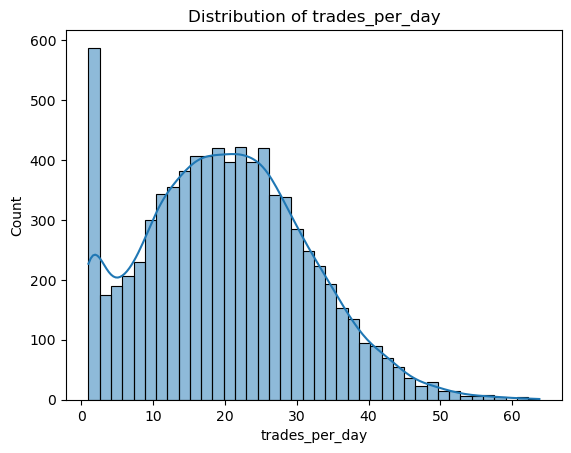

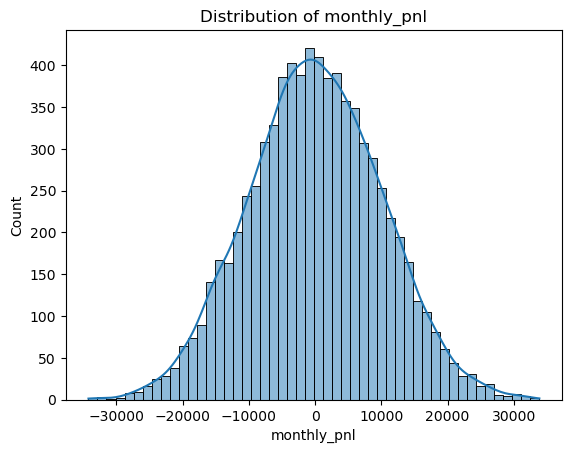

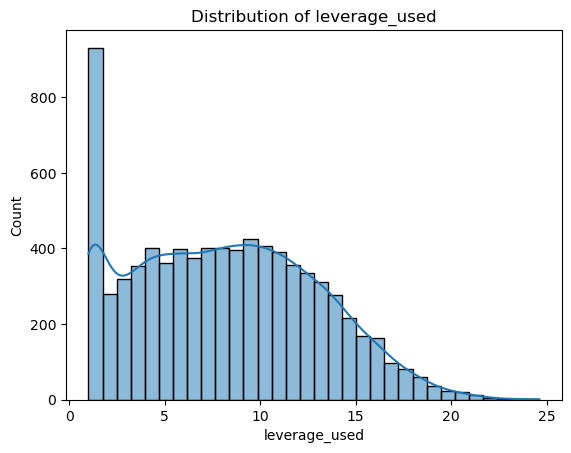

In [17]:
cols = ['trades_per_day', 'monthly_pnl', 'leverage_used']
for col in cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

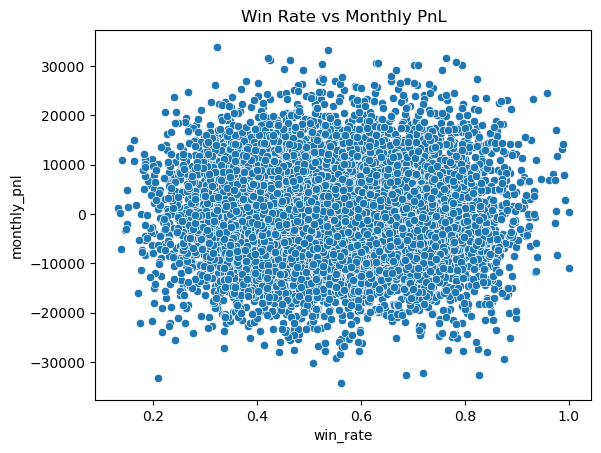

In [20]:
sns.scatterplot(x='win_rate', y='monthly_pnl', data=df)
plt.title("Win Rate vs Monthly PnL")
plt.show()

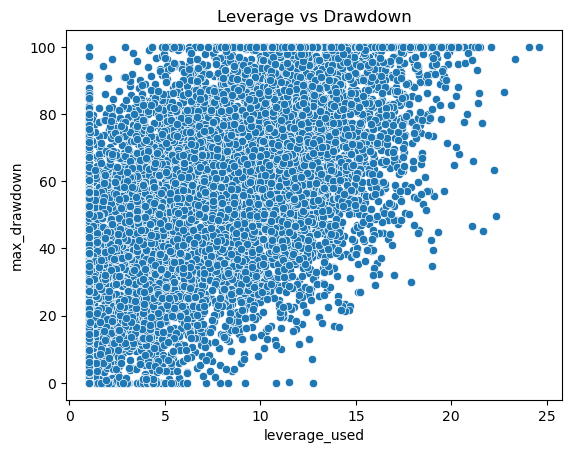

In [21]:
sns.scatterplot(x='leverage_used', y='max_drawdown', data=df)
plt.title("Leverage vs Drawdown")
plt.show()

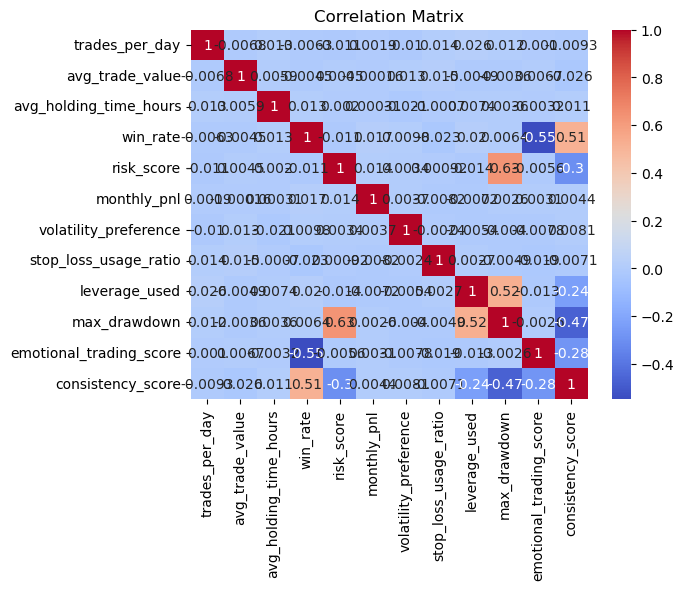

In [24]:
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

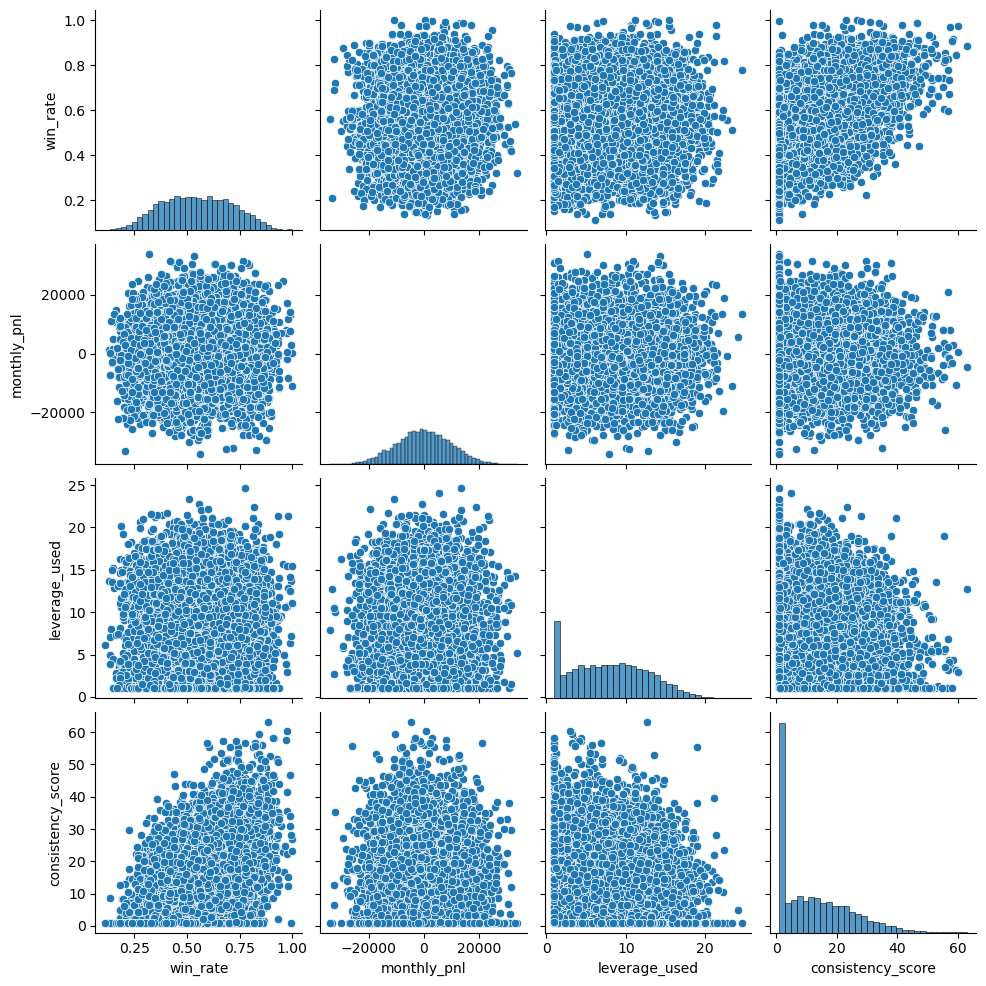

In [27]:
sns.pairplot(df[['win_rate', 'monthly_pnl', 'leverage_used', 'consistency_score']])
plt.show()

In [28]:
imputer = SimpleImputer(strategy='mean')
df[['win_rate', 'monthly_pnl']] = imputer.fit_transform(
    df[['win_rate', 'monthly_pnl']]
)

In [29]:
df = df.drop(columns=['trader_id'], errors='ignore')

In [31]:
for col in ['leverage_used', 'monthly_pnl']:
    df[col] = df[col].clip(
        df[col].quantile(0.25) - 1.5*(df[col].quantile(0.75)-df[col].quantile(0.25)),
        df[col].quantile(0.75) + 1.5*(df[col].quantile(0.75)-df[col].quantile(0.25)))

In [32]:
df[['leverage_used', 'monthly_pnl']].describe()

,leverage_used,monthly_pnl
count,8000.000000,8000.000000
mean,8.117319,28.082579
std,4.768607,9663.280602
min,1.000000,-25370.493750
25%,4.180000,-6310.807500
50%,7.990000,32.611272
75%,11.640000,6395.650000
max,22.830000,25455.336250


In [33]:
df = pd.get_dummies(df, drop_first=True)

In [34]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)

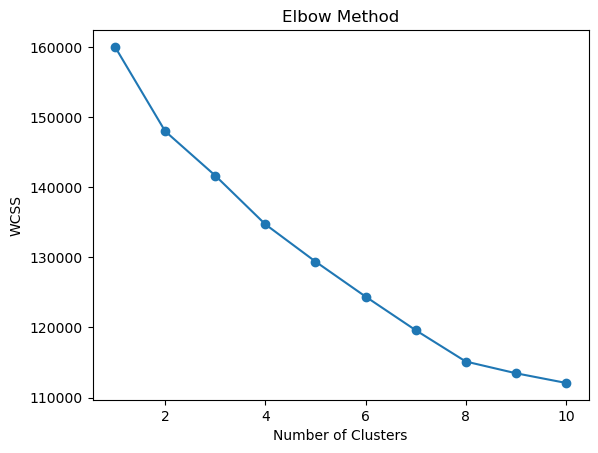

In [35]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [36]:
kmeans = KMeans(n_clusters=4, random_state=42)
df['kmeans_cluster'] = kmeans.fit_predict(scaled_df)

In [38]:
cluster_summary = df.groupby('kmeans_cluster').mean()
cluster_summary

,trades_per_day,avg_trade_value,avg_holding_time_hours,win_rate,risk_score,monthly_pnl,volatility_preference,stop_loss_usage_ratio,leverage_used,max_drawdown,emotional_trading_score,consistency_score,market_type_Equity,market_type_Forex,market_type_Options,trader_style_day_trader,trader_style_high_risk,trader_style_long_term,trader_style_scalper,trader_style_swing_trader
kmeans_cluster,,,,,,,,,,,,,,,,,,,,
0,20.235957,7929.211868,13.451352,0.526131,5.926508,152.491681,0.588089,0.546472,8.714554,62.053260,29.213186,9.812981,0.000000,0.000000,1.000000,0.152186,0.155026,0.185122,0.165815,0.166383
1,20.402147,8103.333170,14.756239,0.655061,3.500132,68.893917,0.598604,0.542954,5.558017,32.632563,19.087922,26.414114,0.256329,0.185127,0.135549,0.163502,0.163502,0.140823,0.152426,0.190928
2,20.280981,8019.650842,14.067753,0.503174,6.353303,-58.083328,0.590988,0.548056,9.165351,66.830368,30.986531,7.016892,0.534386,0.000000,0.000000,0.159714,0.177753,0.163097,0.168734,0.163848
3,19.520268,8150.642212,13.534804,0.521531,5.955642,-11.855143,0.591067,0.555755,8.718918,63.040410,30.071700,9.340345,0.000000,1.000000,0.000000,0.161712,0.162307,0.175386,0.175386,0.156361


In [39]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(scaled_df)

In [40]:
df['dbscan_cluster'].value_counts()

dbscan_cluster
-1    8000
Name: count, dtype: int64

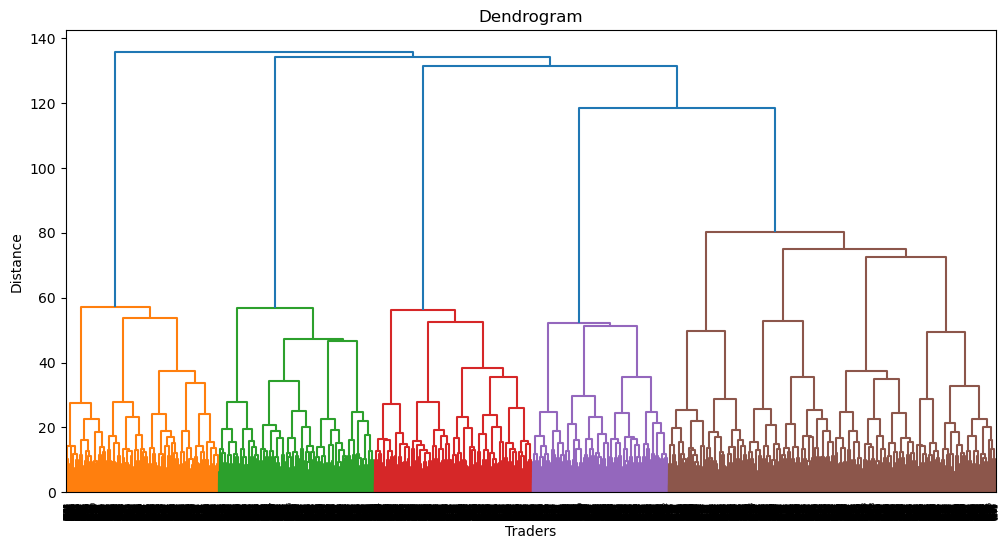

In [41]:
plt.figure(figsize=(12,6))
sch.dendrogram(sch.linkage(scaled_df, method='ward'))
plt.title("Dendrogram")
plt.xlabel("Traders")
plt.ylabel("Distance")
plt.show()

In [43]:
hc = AgglomerativeClustering(n_clusters=4, linkage='ward')
df['hierarchical_cluster'] = hc.fit_predict(scaled_df)

In [45]:
cluster_summary = df.groupby('kmeans_cluster').mean()
cluster_summary

,trades_per_day,avg_trade_value,avg_holding_time_hours,win_rate,risk_score,monthly_pnl,volatility_preference,stop_loss_usage_ratio,leverage_used,max_drawdown,...,market_type_Equity,market_type_Forex,market_type_Options,trader_style_day_trader,trader_style_high_risk,trader_style_long_term,trader_style_scalper,trader_style_swing_trader,dbscan_cluster,hierarchical_cluster
kmeans_cluster,,,,,,,,,,,,,,,,,,,,,
0,20.235957,7929.211868,13.451352,0.526131,5.926508,152.491681,0.588089,0.546472,8.714554,62.053260,...,0.000000,0.000000,1.000000,0.152186,0.155026,0.185122,0.165815,0.166383,-1.0,0.989211
1,20.402147,8103.333170,14.756239,0.655061,3.500132,68.893917,0.598604,0.542954,5.558017,32.632563,...,0.256329,0.185127,0.135549,0.163502,0.163502,0.140823,0.152426,0.190928,-1.0,1.031118
2,20.280981,8019.650842,14.067753,0.503174,6.353303,-58.083328,0.590988,0.548056,9.165351,66.830368,...,0.534386,0.000000,0.000000,0.159714,0.177753,0.163097,0.168734,0.163848,-1.0,1.027809
3,19.520268,8150.642212,13.534804,0.521531,5.955642,-11.855143,0.591067,0.555755,8.718918,63.040410,...,0.000000,1.000000,0.000000,0.161712,0.162307,0.175386,0.175386,0.156361,-1.0,0.972652


In [46]:
for i in df['kmeans_cluster'].unique():
    print(f"\nCluster {i}")
    print(df[df['kmeans_cluster'] == i].mean())


Cluster 0
trades_per_day                 20.235957
avg_trade_value              7929.211868
avg_holding_time_hours         13.451352
win_rate                        0.526131
risk_score                      5.926508
monthly_pnl                   152.491681
volatility_preference           0.588089
stop_loss_usage_ratio           0.546472
leverage_used                   8.714554
max_drawdown                   62.053260
emotional_trading_score        29.213186
consistency_score               9.812981
market_type_Equity              0.000000
market_type_Forex               0.000000
market_type_Options             1.000000
trader_style_day_trader         0.152186
trader_style_high_risk          0.155026
trader_style_long_term          0.185122
trader_style_scalper            0.165815
trader_style_swing_trader       0.166383
kmeans_cluster                  0.000000
dbscan_cluster                 -1.000000
hierarchical_cluster            0.989211
dtype: float64

Cluster 2
trades_per_day      